In [2]:
# ===============================
# 1. LIBRERÍAS
# ===============================
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [3]:
# ===============================
# 2. CARGA DE DATOS
# ===============================
ruta = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\1_datos_semana_epi_meteo\datos_vif\datos_meteo_epi_vif.xlsx"
df_epi_meteo_semanal_vif = pd.read_excel(ruta)
df_epi_meteo_semanal_vif.head()


,fecha,año,semana_epi,casos_dengue,temp_max,hum_esp,prec,dias_lluvia,vel_vi_max,sst
0,2021-01-03,2021,1,0,34.200000,16.367143,7.73,1,0.268571,-1.060214
1,2021-01-10,2021,2,0,34.910000,17.318571,19.18,5,0.204286,-1.058352
2,2021-01-17,2021,3,1,36.372857,16.122857,0.80,0,0.227143,-0.931407
3,2021-01-24,2021,4,0,35.978571,16.564286,12.81,5,0.220000,-0.837360
4,2021-01-31,2021,5,0,35.882857,17.311429,18.06,3,0.225714,-0.897892


In [4]:
df_epi_meteo_semanal_vif.columns

Index(['fecha', 'año', 'semana_epi', 'casos_dengue', 'temp_max', 'hum_esp',
       'prec', 'dias_lluvia', 'vel_vi_max', 'sst'],
      dtype='object')

In [12]:
# ====================== 1. COPIA DE SEGURIDAD ======================
df_procesados = df_epi_meteo_semanal_vif.copy()

# ====================== 2. VARIABLE OBJETIVO (Y) ======================
# Aplicamos SOLO logaritmo para suavizar los picos epidémicos.
# (Se queda en su escala logarítmica original, lista para la CCF)
df_procesados['casos_ln'] = np.log(df_procesados['casos_dengue'] + 1)

print("✅ Variable objetivo 'casos_ln' generada (Solo Logaritmo).")
print("⚠️ Nota: Las variables meteorológicas se mantienen en su escala original porque la CCF de Spearman es invariante a la escala.")

# ====================== 3. VISTA PREVIA DE LOS DATOS LISTOS PARA CCF ======================
print("\n=== Dataset listo para análisis de rezagos (CCF) ===")
print(df_procesados[['año', 'semana_epi', 'casos_ln', 'temp_max', 'prec', 'hum_esp', 'dias_lluvia', 'vel_vi_max', 'sst']].head())

✅ Variable objetivo 'casos_ln' generada (Solo Logaritmo).
⚠️ Nota: Las variables meteorológicas se mantienen en su escala original porque la CCF de Spearman es invariante a la escala.

=== Dataset listo para análisis de rezagos (CCF) ===
    año  semana_epi  casos_ln   temp_max   prec    hum_esp  dias_lluvia  \
0  2021           1  0.000000  34.200000   7.73  16.367143            1   
1  2021           2  0.000000  34.910000  19.18  17.318571            5   
2  2021           3  0.693147  36.372857   0.80  16.122857            0   
3  2021           4  0.000000  35.978571  12.81  16.564286            5   
4  2021           5  0.000000  35.882857  18.06  17.311429            3   

   vel_vi_max       sst  
0    0.268571 -1.060214  
1    0.204286 -1.058352  
2    0.227143 -0.931407  
3    0.220000 -0.837360  
4    0.225714 -0.897892  


In [15]:
print(df_procesados['casos_ln'])

0      0.000000
1      0.000000
2      0.693147
3      0.000000
4      0.000000
         ...   
256    2.197225
257    2.302585
258    2.079442
259    1.791759
260    2.302585
Name: casos_ln, Length: 261, dtype: float64


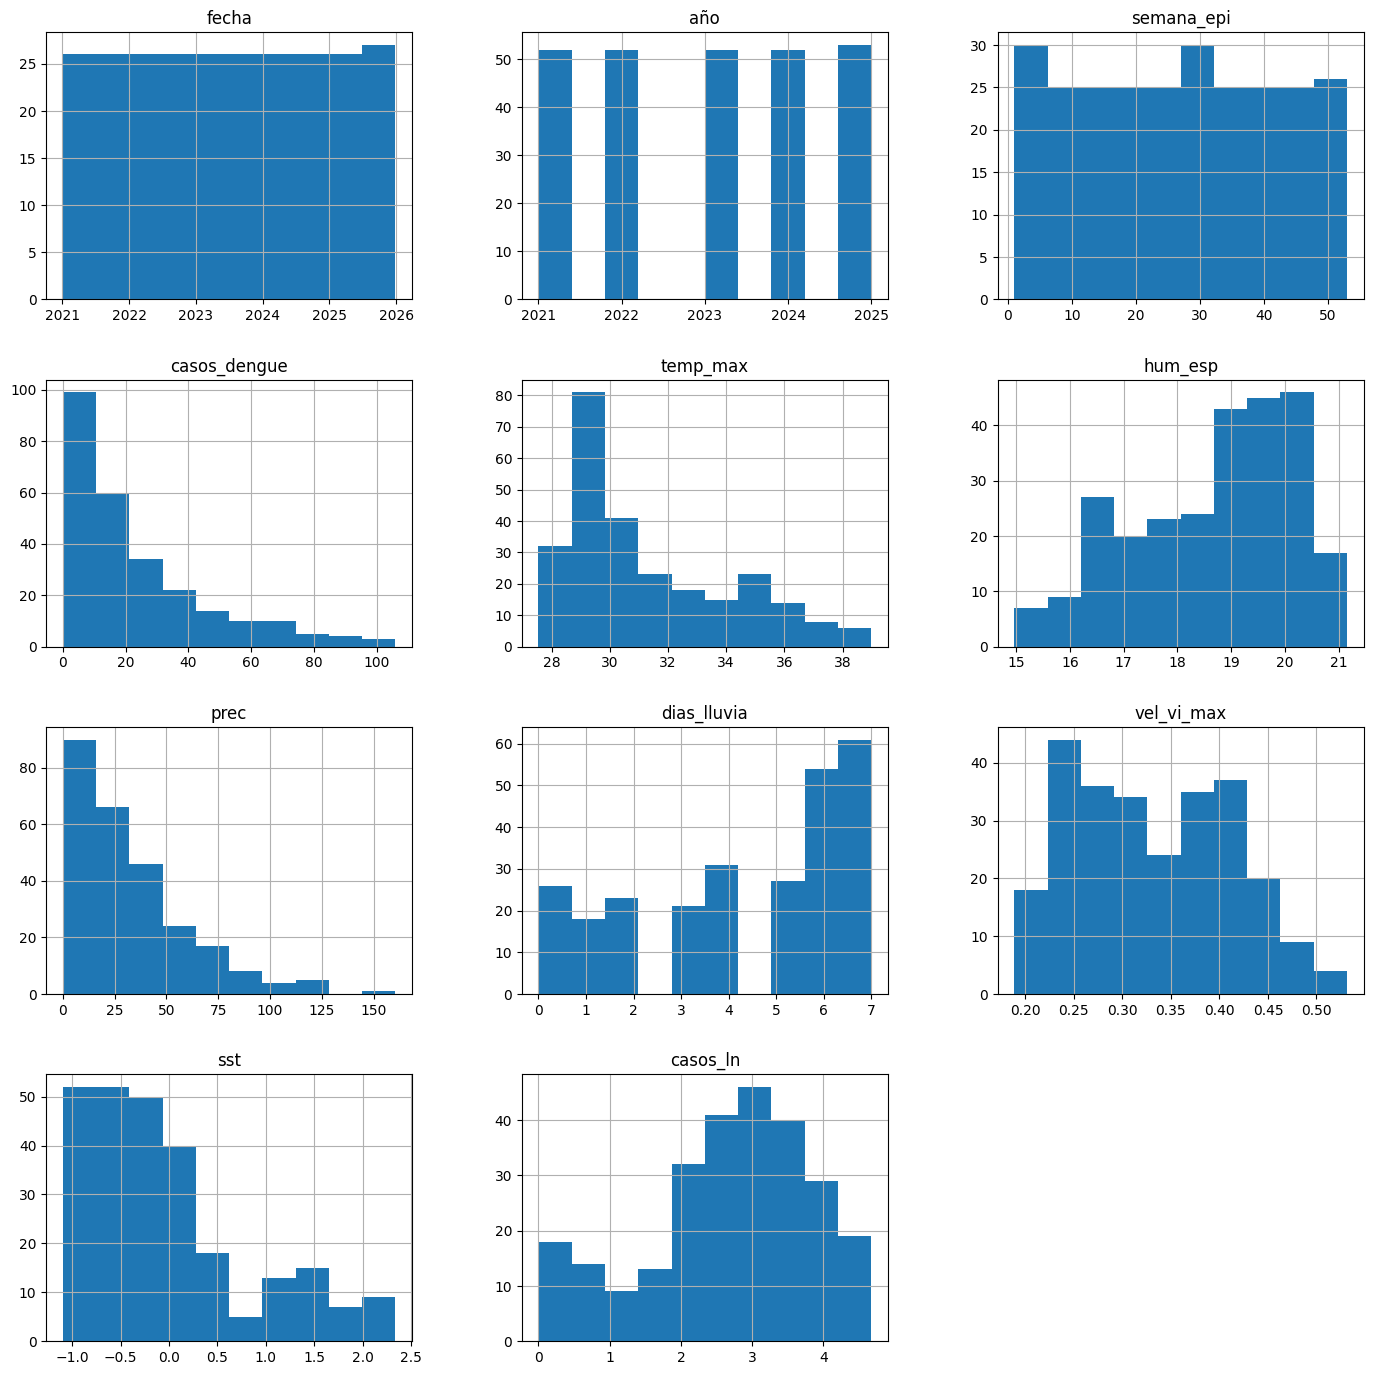

In [13]:
# Histogramas de todas las variables
df_procesados.hist(figsize=(17,17))
# plt.savefig(f"{ubicacion_imagenes_janis}/1.histogramas_procesados_sin_rezagos.png")
plt.show() 


🚀 Ejecutando análisis y generando gráficos...



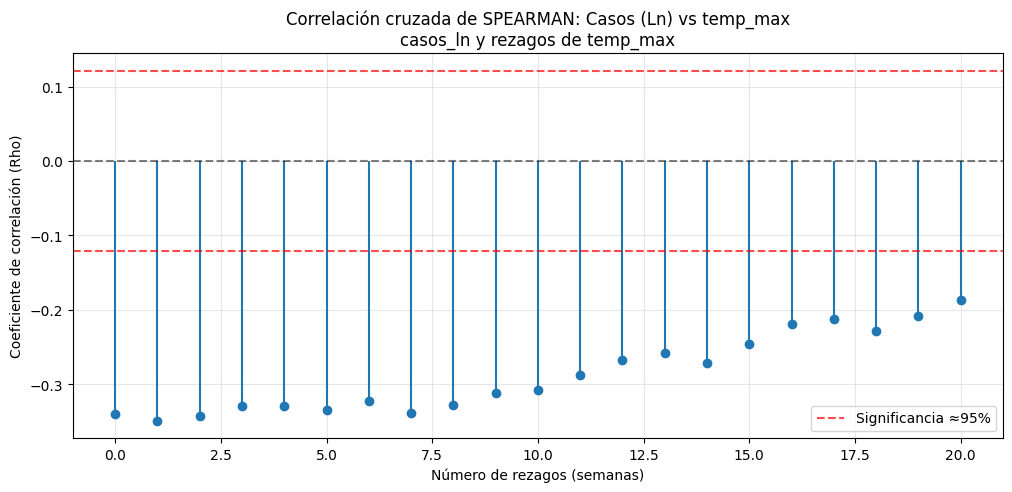


=== Rezagos de Spearman más relevantes para casos_ln vs temp_max ===
Lag  0: -0.3397
Lag  1: -0.3488
Lag  2: -0.3428
Lag  3: -0.3289
Lag  4: -0.3296
Lag  5: -0.3343
Lag  6: -0.3223
Lag  7: -0.3379
Lag  8: -0.3273
Lag  9: -0.3113
Lag 10: -0.3076
Lag 11: -0.2873
Lag 12: -0.2675
Lag 13: -0.2584
Lag 14: -0.2709
Lag 15: -0.2452
Lag 16: -0.2192
Lag 17: -0.2126
Lag 18: -0.2289
Lag 19: -0.2075
Lag 20: -0.1861


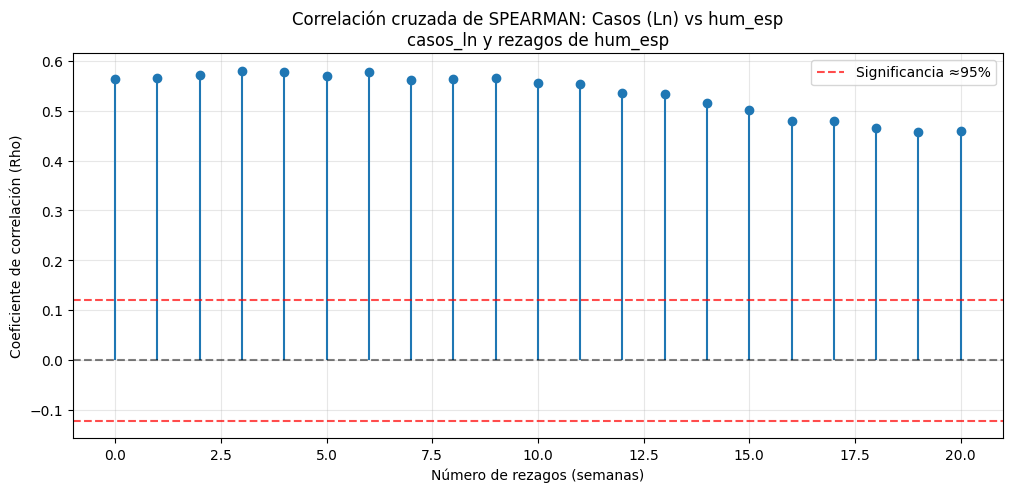


=== Rezagos de Spearman más relevantes para casos_ln vs hum_esp ===
Lag  0: +0.5641
Lag  1: +0.5658
Lag  2: +0.5707
Lag  3: +0.5799
Lag  4: +0.5772
Lag  5: +0.5684
Lag  6: +0.5769
Lag  7: +0.5617
Lag  8: +0.5636
Lag  9: +0.5661
Lag 10: +0.5551
Lag 11: +0.5536
Lag 12: +0.5344
Lag 13: +0.5332
Lag 14: +0.5153
Lag 15: +0.5015
Lag 16: +0.4797
Lag 17: +0.4785
Lag 18: +0.4648
Lag 19: +0.4566
Lag 20: +0.4589


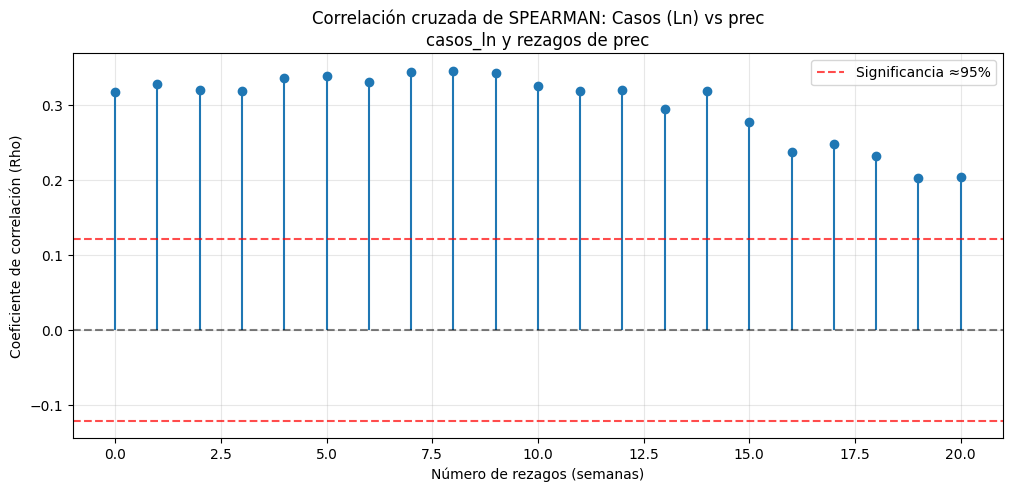


=== Rezagos de Spearman más relevantes para casos_ln vs prec ===
Lag  0: +0.3171
Lag  1: +0.3283
Lag  2: +0.3197
Lag  3: +0.3191
Lag  4: +0.3357
Lag  5: +0.3387
Lag  6: +0.3313
Lag  7: +0.3445
Lag  8: +0.3458
Lag  9: +0.3427
Lag 10: +0.3254
Lag 11: +0.3193
Lag 12: +0.3201
Lag 13: +0.2951
Lag 14: +0.3184
Lag 15: +0.2772
Lag 16: +0.2371
Lag 17: +0.2484
Lag 18: +0.2326
Lag 19: +0.2026
Lag 20: +0.2035


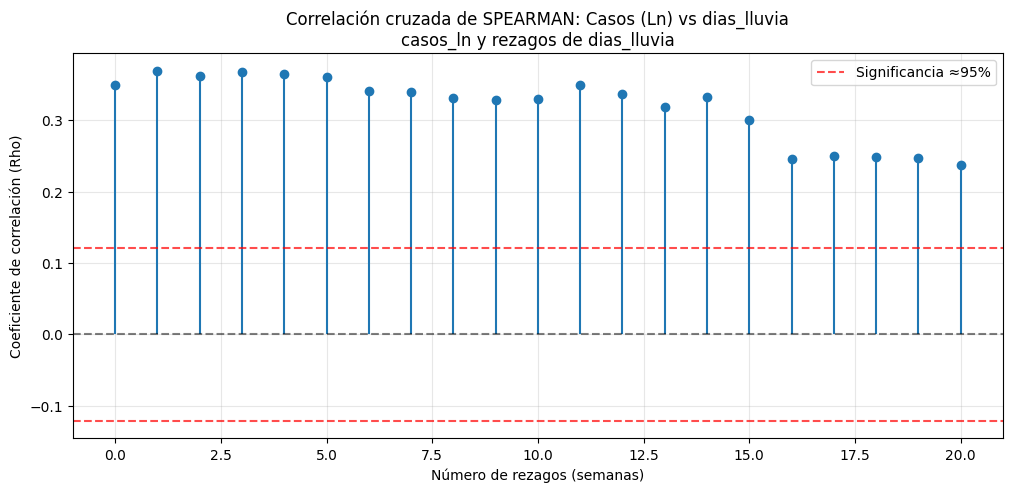


=== Rezagos de Spearman más relevantes para casos_ln vs dias_lluvia ===
Lag  0: +0.3488
Lag  1: +0.3695
Lag  2: +0.3621
Lag  3: +0.3678
Lag  4: +0.3654
Lag  5: +0.3607
Lag  6: +0.3414
Lag  7: +0.3403
Lag  8: +0.3316
Lag  9: +0.3287
Lag 10: +0.3303
Lag 11: +0.3499
Lag 12: +0.3370
Lag 13: +0.3188
Lag 14: +0.3332
Lag 15: +0.3006
Lag 16: +0.2454
Lag 17: +0.2499
Lag 18: +0.2492
Lag 19: +0.2473
Lag 20: +0.2366


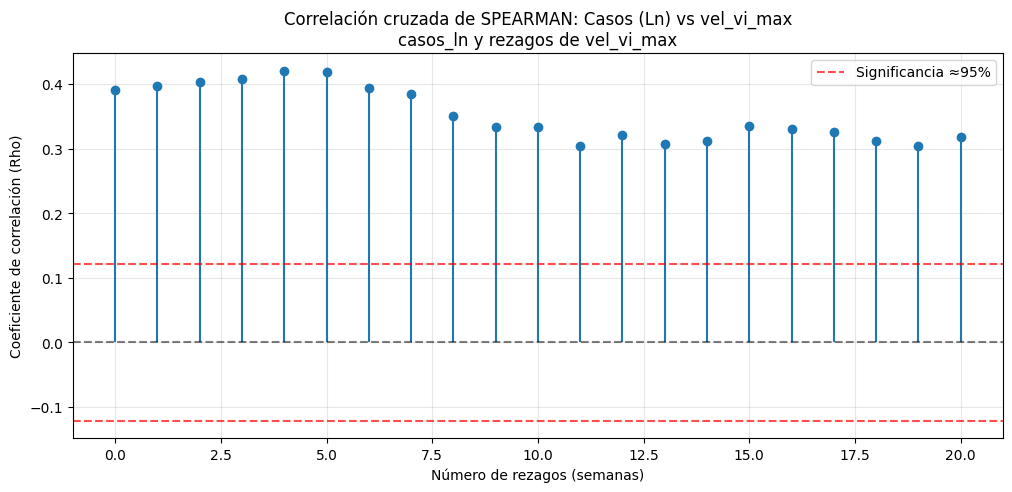


=== Rezagos de Spearman más relevantes para casos_ln vs vel_vi_max ===
Lag  0: +0.3916
Lag  1: +0.3966
Lag  2: +0.4030
Lag  3: +0.4078
Lag  4: +0.4210
Lag  5: +0.4196
Lag  6: +0.3949
Lag  7: +0.3844
Lag  8: +0.3509
Lag  9: +0.3333
Lag 10: +0.3344
Lag 11: +0.3041
Lag 12: +0.3210
Lag 13: +0.3071
Lag 14: +0.3127
Lag 15: +0.3348
Lag 16: +0.3306
Lag 17: +0.3258
Lag 18: +0.3115
Lag 19: +0.3047
Lag 20: +0.3178


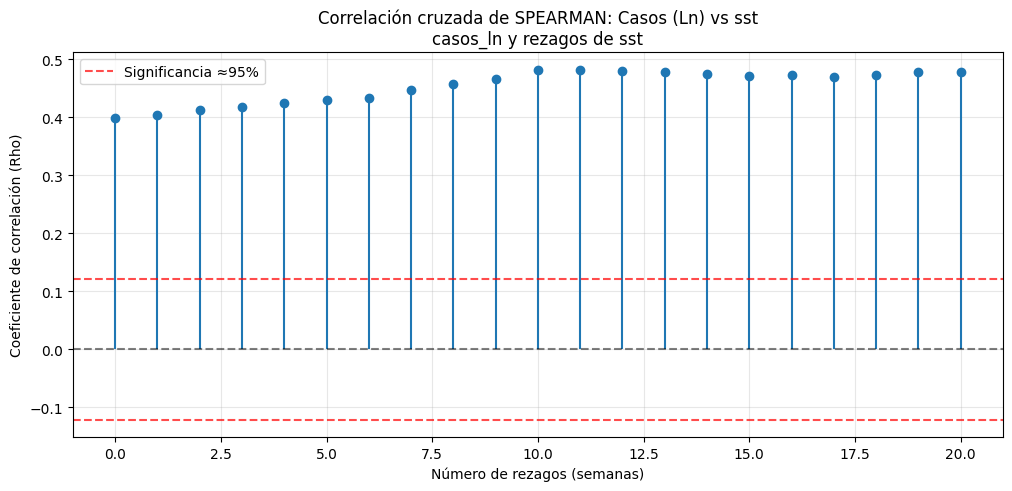


=== Rezagos de Spearman más relevantes para casos_ln vs sst ===
Lag  0: +0.3979
Lag  1: +0.4032
Lag  2: +0.4130
Lag  3: +0.4179
Lag  4: +0.4241
Lag  5: +0.4298
Lag  6: +0.4327
Lag  7: +0.4469
Lag  8: +0.4578
Lag  9: +0.4666
Lag 10: +0.4818
Lag 11: +0.4817
Lag 12: +0.4796
Lag 13: +0.4786
Lag 14: +0.4745
Lag 15: +0.4713
Lag 16: +0.4734
Lag 17: +0.4701
Lag 18: +0.4727
Lag 19: +0.4782
Lag 20: +0.4775


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# =====================================================================
# 1. DEFINICIÓN DE LA FUNCIÓN (La receta que le faltaba a Python)
# =====================================================================
def plot_cross_correlation(df, var_x, var_y, max_lags=20, title=""):
    """
    Calcula y grafica la correlación cruzada de Spearman entre dos series (solo lags positivos)
    """
    # Eliminar NaN para evitar errores en el cálculo
    data = df[[var_x, var_y]].dropna()
    
    lags_pos = np.arange(0, max_lags + 1)
    corr_pos = []
    n_total = len(data)
    
    # Calcular correlación de Spearman rezago por rezago
    for lag in lags_pos:
        if lag == 0:
            x_shifted = data[var_x].values
            y_shifted = data[var_y].values
        else:
            x_shifted = data[var_x].values[:-lag]
            y_shifted = data[var_y].values[lag:]
            
        coef, _ = spearmanr(x_shifted, y_shifted)
        corr_pos.append(coef)
        
    corr_pos = np.array(corr_pos)
    
    # Graficar el STEM plot
    plt.figure(figsize=(12, 5))
    plt.stem(lags_pos, corr_pos, basefmt=" ")
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Intervalo de confianza aproximado ≈95%
    plt.axhline(y=1.96/np.sqrt(n_total), color='red', linestyle='--', alpha=0.7, label='Significancia ≈95%')
    plt.axhline(y=-1.96/np.sqrt(n_total), color='red', linestyle='--', alpha=0.7)
    
    plt.title(f'Correlación cruzada de SPEARMAN: {title}\n{var_y} y rezagos de {var_x}')
    plt.xlabel('Número de rezagos (semanas)')
    plt.ylabel('Coeficiente de correlación (Rho)')
    plt.xlim(-1, max_lags + 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    # Mostrar rezagos relevantes en la consola
    print(f"\n=== Rezagos de Spearman más relevantes para {var_y} vs {var_x} ===")
    for i in range(0, len(corr_pos)):
        if abs(corr_pos[i]) > 0.15:
            sign = "+" if corr_pos[i] > 0 else ""
            print(f"Lag {i:2d}: {sign}{corr_pos[i]:.4f}")

# =====================================================================
# 2. VARIABLES EXÓGENAS A ANALIZAR (Ajustadas tras tu VIF)
# =====================================================================
variables_a_analizar = [
    'temp_max', 'hum_esp', 
    'prec', 'dias_lluvia', 'vel_vi_max', 'sst'
]

print("\n🚀 Ejecutando análisis y generando gráficos...\n")

# =====================================================================
# 3. EJECUTAR EL CICLO SOBRE TU DATAFRAME (Código Corregido)
# =====================================================================
for var in variables_a_analizar:
    plot_cross_correlation(
        df_procesados,          # Nombre de tu DataFrame con logaritmo
        var_x=var,
        var_y='casos_ln',       
        max_lags=20,
        title=f"Casos (Ln) vs {var}"
    )

0      0.000000
1      0.000000
2      0.693147
3      0.000000
4      0.000000
         ...   
256    2.197225
257    2.302585
258    2.079442
259    1.791759
260    2.302585
Name: casos_ln, Length: 261, dtype: float64


In [60]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# =====================================================================
# 1. CREACIÓN TEMPORAL DE LAS VARIABLES CON SUS REZAGOS ÓPTIMOS
# =====================================================================
df_vif_lags = df_procesados.copy()

df_vif_lags['hum_esp_lag3']    = df_vif_lags['hum_esp'].shift(3)
df_vif_lags['prec_lag8']       = df_vif_lags['prec'].shift(8)
df_vif_lags['dias_lluvia_lag1'] = df_vif_lags['dias_lluvia'].shift(1)
df_vif_lags['vel_vi_max_lag4'] = df_vif_lags['vel_vi_max'].shift(4)
df_vif_lags['sst_lag10']       = df_vif_lags['sst'].shift(10)

# =====================================================================
# 2. SELECCIÓN DE COLUMNAS Y LIMPIEZA DE NaNs
# =====================================================================
# Lista de las nuevas variables exógenas con rezago
variables_con_lag = [
    'hum_esp_lag3', 'prec_lag8', 
    'dias_lluvia_lag1', 'vel_vi_max_lag4', 'sst_lag10'
]

# Es obligatorio eliminar las filas con nulos (NaN) generadas por los shifts
X_lags = df_vif_lags[variables_con_lag].dropna()

# =====================================================================
# 3. CÁLCULO DEL VIF
# =====================================================================
# Agregamos la constante requerida por statsmodels
X_lags_const = add_constant(X_lags)

vif_lags_data = pd.DataFrame()
vif_lags_data["Variable (Con Rezagos)"] = X_lags.columns

# Evaluamos el VIF iterando sobre las columnas exógenas
vif_lags_data["VIF"] = [
    variance_inflation_factor(X_lags_const.values, i + 1) 
    for i in range(X_lags.shape[1])
]

# Ordenar los resultados para su lectura
vif_lags_data = vif_lags_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

# =====================================================================
# 4. MOSTRAR RESULTADOS
# =====================================================================
print("\n=== VIF DE VARIABLES METEOROLÓGICAS CON REZAGOS SELECCIONADOS ===")
print(vif_lags_data)


=== VIF DE VARIABLES METEOROLÓGICAS CON REZAGOS SELECCIONADOS ===
  Variable (Con Rezagos)       VIF
0           hum_esp_lag3  2.475757
1       dias_lluvia_lag1  1.507593
2        vel_vi_max_lag4  1.462350
3              prec_lag8  1.399069
4              sst_lag10  1.248077


In [62]:
# Crear una copia limpia y definitiva para el modelado
df_final_modelado = df_procesados.copy()

# 1. Aplicar de forma definitiva los rezagos evaluados en el VIF
df_final_modelado['hum_esp_lag3']    = df_final_modelado['hum_esp'].shift(3)
df_final_modelado['dias_lluvia_lag1'] = df_final_modelado['dias_lluvia'].shift(1)
df_final_modelado['sst_lag10']       = df_final_modelado['sst'].shift(10)
df_final_modelado['vel_vi_max_lag4'] = df_final_modelado['vel_vi_max'].shift(4)
df_final_modelado['prec_lag8']       = df_final_modelado['prec'].shift(8)

# 2. Definir las columnas que nos interesan conservar
columnas_finales = [
    'fecha', 'año', 'semana_epi',    # Identificadores de tiempo
    'casos_ln',                      # VARIABLE OBJETIVO (Y)
    'hum_esp_lag3', # VARIABLES EXÓGENAS (X)
    'dias_lluvia_lag1', 'sst_lag10', 
    'vel_vi_max_lag4', 'prec_lag8'
]

# 3. Filtrar y limpiar filas nulas iniciales producto de los rezagos
df_final_modelado = df_final_modelado[columnas_finales].dropna().reset_index(drop=True)

# 4. Guardar el dataset final listo para modelado
df_final_modelado.to_excel("C:\\Users\\usuario1\\OneDrive - Universidad de Antioquia\\UNIVERSIDAD DE ANTIOQUIA\\Proyecto SAT Dengue\\Bases de datos\\datos_consolidados\\3_datos_modelos\\datos_corr_vif\\datos_correlacion_vif.xlsx", index=False)

print("✅ Dataset consolidado, sin colinealidad y listo para la partición temporal.")
print(f"Dimensiones finales: {df_final_modelado.shape[0]} semanas listas para el análisis.")

✅ Dataset consolidado, sin colinealidad y listo para la partición temporal.
Dimensiones finales: 251 semanas listas para el análisis.


In [63]:
import numpy as np
import pandas as pd
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')



In [65]:
# =====================================================================
# 1. DEFINICIÓN DE MATRICES (Y, X)
# =====================================================================
exog_cols = ['hum_esp_lag3', 'dias_lluvia_lag1', 'sst_lag10', 'vel_vi_max_lag4', 'prec_lag8']
Y = df_final_modelado['casos_ln']
X = df_final_modelado[exog_cols]



In [66]:
# =====================================================================
# 2. DEFINICIÓN EXHAUSTIVA DE MODELOS CANDIDATOS
# =====================================================================
# Formato: (Nombre_Base, orden_regular, orden_estacional, usa_exogenas)
candidatos = [
    # A. Modelos ARIMA puros
    ('ARIMA', (1,1,0), (0,0,0,0), False),
    ('ARIMA', (0,1,1), (0,0,0,0), False),
    ('ARIMA', (1,1,1), (0,0,0,0), False),
    ('ARIMA', (2,1,1), (0,0,0,0), False),
    ('ARIMA', (1,1,2), (0,0,0,0), False),
    ('ARIMA', (2,1,2), (0,0,0,0), False),
    
    # B. Modelos SARIMA (S=52)
    ('SARIMA', (1,1,1), (1,1,1,52), False),
    ('SARIMA', (1,1,0), (1,1,1,52), False),
    ('SARIMA', (0,1,1), (1,1,1,52), False),
    ('SARIMA', (2,1,1), (1,1,1,52), False),
    ('SARIMA', (1,1,2), (1,1,1,52), False),
    ('SARIMA', (1,1,1), (0,1,1,52), False),
    ('SARIMA', (1,1,1), (1,1,0,52), False),
    
    # C. Modelos ARIMAX (Con Clima)
    ('ARIMAX', (1,1,0), (0,0,0,0), True),
    ('ARIMAX', (0,1,1), (0,0,0,0), True),
    ('ARIMAX', (1,1,1), (0,0,0,0), True),
    ('ARIMAX', (2,1,1), (0,0,0,0), True),
    ('ARIMAX', (1,1,2), (0,0,0,0), True),
    
    # D. Modelos SARIMAX (Con Clima + S=52)
    ('SARIMAX', (1,1,1), (1,1,1,52), True),
    ('SARIMAX', (1,1,0), (1,1,1,52), True),
    ('SARIMAX', (0,1,1), (1,1,1,52), True),
    ('SARIMAX', (2,1,1), (1,1,1,52), True),
    ('SARIMAX', (1,1,2), (1,1,1,52), True)
]

split_proportions = [0.80, 0.90, 0.95]
results_list = []

print("🚀 Iniciando Grid Search Estratificado. Esto puede tomar unos minutos debido a S=52...")



🚀 Iniciando Grid Search Estratificado. Esto puede tomar unos minutos debido a S=52...


In [67]:
# =====================================================================
# 3. EJECUCIÓN DEL GRID SEARCH
# =====================================================================
for prop in split_proportions:
    split_idx = int(len(df_final_modelado) * prop)
    split_name = f"{int(prop*100)}-{int((1-prop)*100)}"
    
    # Divisiones temporales
    Y_train, Y_test = Y.iloc[:split_idx], Y.iloc[split_idx:]
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    
    # Valores reales para métricas de salud pública (deshaciendo ln(x+1))
    Y_train_real = np.exp(Y_train.values) - 1
    Y_test_real  = np.exp(Y_test.values) - 1
    
    for tipo, order, s_order, use_exog in candidatos:
        # Construir etiqueta descriptiva del modelo
        label = f"{tipo}{order}" if s_order == (0,0,0,0) else f"{tipo}{order}{s_order}"
        
        try:
            x_train_fit = X_train if use_exog else None
            x_test_pred = X_test if use_exog else None
            
            # Ajuste de modelo candidato
            model = SARIMAX(
                Y_train, 
                exog=x_train_fit, 
                order=order, 
                seasonal_order=s_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            model_fitted = model.fit(disp=False, maxiter=50) # maxiter acota el tiempo de convergencia estacional
            
            # Métricas intrínsecas (vienen del logaritmo)
            aic = model_fitted.aic
            bic = model_fitted.bic
            
            # Test Ljung-Box en residuos
            lb_df = acorr_ljungbox(model_fitted.resid, lags=[10], return_df=True)
            lb_pvalue = lb_df['lb_pvalue'].values[0]
            
            # Predicciones
            pred_train_ln = model_fitted.fittedvalues
            pred_test_ln  = model_fitted.forecast(steps=len(Y_test), exog=x_test_pred)
            
            # Conversión obligatoria a escala física real (Casos)
            pred_train_real = np.maximum(0, np.exp(pred_train_ln.values) - 1)
            pred_test_real  = np.maximum(0, np.exp(pred_test_ln.values) - 1)
            
            # --- CÁLCULO RIGUROSO DE MÉTRICAS SOBRE CASOS REALES ---
            # Entrenamiento
            train_rmse = np.sqrt(mean_squared_error(Y_train_real, pred_train_real))
            train_mae  = mean_absolute_error(Y_train_real, pred_train_real)
            train_r2   = r2_score(Y_train_real, pred_train_real)
            train_mape = np.mean(np.abs((Y_train_real - pred_train_real) / np.where(Y_train_real == 0, 1, Y_train_real))) * 100
            
            # Testeo
            test_rmse = np.sqrt(mean_squared_error(Y_test_real, pred_test_real))
            test_mae  = mean_absolute_error(Y_test_real, pred_test_real)
            test_r2   = r2_score(Y_test_real, pred_test_real)
            test_mape = np.mean(np.abs((Y_test_real - pred_test_real) / np.where(Y_test_real == 0, 1, Y_test_real))) * 100
            
            results_list.append({
                'Partición': split_name,
                'Modelo Config': label,
                'AIC': aic,
                'BIC': bic,
                'Ljung-Box (p-val)': lb_pvalue,
                'Train RMSE': train_rmse,
                'Train MAE': train_mae,
                'Train MAPE (%)': train_mape,
                'Train R2': train_r2,
                'Test RMSE': test_rmse,
                'Test MAE': test_mae,
                'Test MAPE (%)': test_mape,
                'Test R2': test_r2
            })
            
        except Exception as e:
            # Si un modelo específico no converge estadísticamente, pasa al siguiente sin romper el ciclo
            continue



In [70]:
# Consolidación final
df_grid_resultados = pd.DataFrame(results_list)
# Ordenar por el menor error predictivo en validación (Test RMSE)
df_grid_resultados = df_grid_resultados.sort_values(by=['Partición', 'Test RMSE'], ascending=[True, True]).reset_index(drop=True)




In [71]:
import numpy as np
import pandas as pd
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.formatting.rule import ColorScaleRule

# Ruta específica para el proyecto SAT Dengue
ruta_excel = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\modelos\modelo_corr_vif\modelo_corr_vif.xlsx"

print("\n📊 ¡Grid Search finalizado con éxito! Generando reporte multi-pestaña en Excel...")

# =====================================================================
# 5. CREACIÓN DEL ARCHIVO EXCEL MULTI-PESTAÑA CON PANDAS
# =====================================================================
# Agrupamos los datos por partición para escribirlos por separado
df_grid_resultados = pd.DataFrame(results_list)

with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    for prop in split_proportions:
        split_name = f"{int(prop*100)}-{int((1-prop)*100)}"
        nombre_hoja = f"Partición {split_name}"
        
        # Filtrar datos de la partición actual y ordenarlos por el mejor Test RMSE
        df_particion = df_grid_resultados[df_grid_resultados['Partición'] == split_name].copy()
        df_particion = df_particion.sort_values(by='Test RMSE', ascending=True).reset_index(drop=True)
        
        # Escribir la partición en su propia pestaña
        df_particion.to_excel(writer, sheet_name=nombre_hoja, index=False)

# =====================================================================
# 6. DISEÑO ESTILIZADO E INDEPENDIENTE POR HOJA CON OPENPYXL
# =====================================================================
wb = openpyxl.load_workbook(ruta_excel)

# --- CONFIGURACIÓN DE ESTILOS ACADÉMICOS (Azul Universitario) ---
HEADER_FILL = PatternFill(start_color="1F4E79", end_color="1F4E79", fill_type="solid")
HEADER_FONT = Font(name="Segoe UI", size=11, bold=True, color="FFFFFF")
ZEBRA_FILL  = PatternFill(start_color="F2F5F8", end_color="F2F5F8", fill_type="solid")
WHITE_FILL  = PatternFill(start_color="FFFFFF", end_color="FFFFFF", fill_type="solid")
DATA_FONT   = Font(name="Segoe UI", size=10, color="000000")

THIN_BORDER = Border(
    left=Side(style='thin', color='D9D9D9'),
    right=Side(style='thin', color='D9D9D9'),
    top=Side(style='thin', color='D9D9D9'),
    bottom=Side(style='thin', color='D9D9D9')
)

# Iterar sobre cada hoja creada para aplicar formatos personalizados
for ws in wb.worksheets:
    # Activar filtros automáticos y congelar la cabecera
    ws.auto_filter.ref = f"A1:{get_column_letter(ws.max_column)}{ws.max_row}"
    ws.freeze_panes = "A2"
    
    # Aplicar fuentes, bordes y colores según fila (Zebra striping)
    for row_idx, row in enumerate(ws.iter_rows(min_row=1, max_row=ws.max_row, min_col=1, max_col=ws.max_column), start=1):
        is_header = (row_idx == 1)
        current_fill = HEADER_FILL if is_header else (ZEBRA_FILL if row_idx % 2 == 0 else WHITE_FILL)
        
        for col_idx, cell in enumerate(row, start=1):
            cell.fill = current_fill
            cell.border = THIN_BORDER
            
            if is_header:
                cell.font = HEADER_FONT
                cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
            else:
                cell.font = DATA_FONT
                # Alineaciones y formatos numéricos rigurosos
                if col_idx in [1, 2]:  # Partición y Configuración
                    cell.alignment = Alignment(horizontal="left", vertical="center")
                elif col_idx in [3, 4]:  # AIC, BIC
                    cell.number_format = '#,##0.0000'
                    cell.alignment = Alignment(horizontal="right", vertical="center")
                elif col_idx == 5:  # Ljung-Box (p-valor)
                    cell.number_format = '0.0000'
                    cell.alignment = Alignment(horizontal="right", vertical="center")
                elif col_idx in [6, 7, 10, 11]:  # RMSEs y MAEs (Casos reales)
                    cell.number_format = '#,##0.0000'
                    cell.alignment = Alignment(horizontal="right", vertical="center")
                elif col_idx in [8, 12]:  # MAPEs (%)
                    cell.number_format = '0.00"%"'
                    cell.alignment = Alignment(horizontal="right", vertical="center")
                elif col_idx in [9, 13]:  # Coeficientes R2
                    cell.number_format = '0.0000'
                    cell.alignment = Alignment(horizontal="right", vertical="center")
                    
    ws.row_dimensions[1].height = 28  # Altura de cabecera
    
    # Auto-ajuste del ancho de columnas
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        col_letter = get_column_letter(col[0].column)
        ws.column_dimensions[col_letter].width = max(max_len + 4, 12)
        
    # --- FORMATEO CONDICIONAL INDEPENDIENTE POR HOJA ---
    # Columna M (Test R2) -> Gradiente Verde (Valores altos = Mejor)
    color_scale_r2 = ColorScaleRule(start_type='num', start_value=0, start_color='FFFFFF',
                                     end_type='num', end_value=1, end_color='C6EFCE')
    ws.conditional_formatting.add(f"M2:M{ws.max_row}", color_scale_r2)
    
    # Columna J (Test RMSE) -> Gradiente Rojo (Valores bajos = Mejor)
    # Extraemos min y max de los datos escritos directo en la hoja para ajustar la escala localmente
    valores_rmse = [ws.cell(row=r, column=10).value for r in range(2, ws.max_row + 1) if ws.cell(row=r, column=10).value is not None]
    if valores_rmse:
        color_scale_rmse = ColorScaleRule(start_type='num', start_value=min(valores_rmse), start_color='FFFFFF',
                                           end_type='num', end_value=max(valores_rmse), end_color='FFC7CE')
        ws.conditional_formatting.add(f"J2:J{ws.max_row}", color_scale_rmse)

# Guardar los cambios definitivos en el libro multidimensional
wb.save(ruta_excel)

print(f"💾 Libro de Excel modificado con éxito. Hojas creadas: {wb.sheetnames}")


📊 ¡Grid Search finalizado con éxito! Generando reporte multi-pestaña en Excel...
💾 Libro de Excel modificado con éxito. Hojas creadas: ['Partición 80-19', 'Partición 90-9', 'Partición 95-5']
